
## CLNSIG – Dataset Bàsic (sense anotació VEP)
Aquest notebook entrena els sis models de classificació per a la 
predicció de significança clínica sobre el dataset 
bàsic, que no inclou les anotacions funcionals VEP.

## Imports

In [3]:
import os
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold,
    cross_val_score, train_test_split
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

/Users/eliag/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Càrrega de dades i preparació del dataset

In [4]:
df = pd.read_csv("../data/raw/clinvar_clnsig_annotated.csv")
# Crear dataset bàsic (sense columnes VEP) a partir de df annotated
vep_cols = [
    "Allele", "Consequence", "IMPACT", "SYMBOL", "Feature_type", "Feature",
    "BIOTYPE", "EXON", "INTRON", "cDNA_position", "CDS_position",
    "Protein_position", "Amino_acids", "Codons", "STRAND", "BAM_EDIT",
    "SIFT", "PolyPhen", "LoFtool", "CADD_PHRED", "CADD_RAW", "BLOSUM62"
]

df_basic = df.drop(columns=[c for c in vep_cols if c in df.columns])
df_basic.to_csv("../data/raw/clinvar_clnsig_basic.csv", index=False)

print("Annotated shape:", df.shape)
print("Basic shape:    ", df_basic.shape)
print("Columnes eliminades:", [c for c in vep_cols if c in df.columns])


Annotated shape: (60480, 47)
Basic shape:     (60480, 25)
Columnes eliminades: ['Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'LoFtool', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62']


## Distribució de la variable objectiu (CLNSIG)

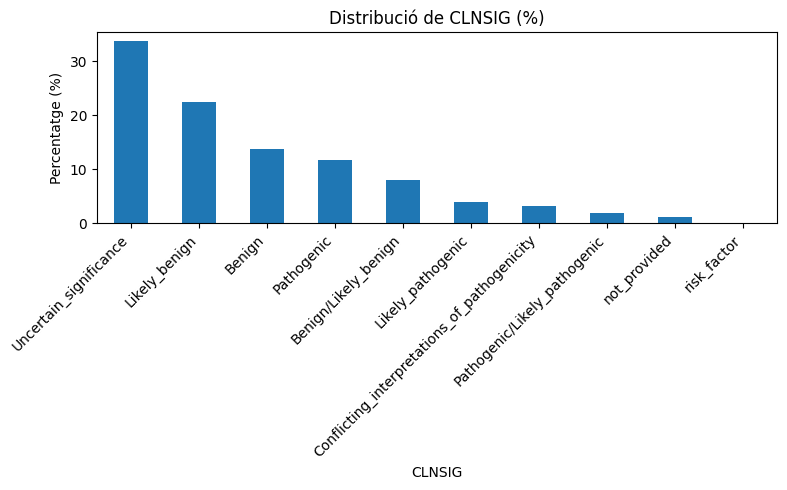

In [5]:
counts = df_basic["CLNSIG"].value_counts(dropna=False)
percent = (counts / counts.sum()) * 100
top_percent = percent.head(10)

plt.figure(figsize=(8,5))
top_percent.plot(kind="bar")

plt.title("Distribució de CLNSIG (%)")
plt.ylabel("Percentatge (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Creació Classes i Partició de dades  

In [6]:
# Valors que pertanyen a cada classe
benign_values = [
    "Benign", "Likely_benign", "Benign/Likely_benign",
    "Benign,_risk_factor", "Benign,_other", "Benign,_association",
    "Benign/Likely_benign,_risk_factor", "Benign/Likely_benign,_other",
    "Likely_benign,_risk_factor", "Likely_benign,_association"
]
vus_values = [
    "Uncertain_significance"
]
pathogenic_values = [
    "Pathogenic", "Likely_pathogenic", "Pathogenic/Likely_pathogenic",
    "Pathogenic,_risk_factor", "Pathogenic/Likely_pathogenic,_risk_factor",
    "Pathogenic,_association"
]

clnsig_map = (
    {v: 0 for v in benign_values} |
    {v: 1 for v in vus_values}    |
    {v: 2 for v in pathogenic_values}
)

# Filtrar i crear target (descartem Conflicting, not_provided, etc.)
df_multi_basic = df_basic[df_basic["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi_basic["CLNSIG_target"] = df_multi_basic["CLNSIG"].map(clnsig_map)

# Comprovació distribució
print(df_multi_basic["CLNSIG_target"].value_counts())
print(df_multi_basic["CLNSIG_target"].value_counts(normalize=True).round(3))

# Columnes a eliminar: target, CLASS antiga, i les que revelarien el resultat
cols_to_drop = ["CLNSIG", "CLNSIG_target", "CLASS"]

for col in ["CLNSIGCONF", "CLNREVSTAT"]:
    if col in df_multi_basic.columns:
        cols_to_drop.append(col)

X = df_multi_basic.drop(columns=cols_to_drop)
y = df_multi_basic["CLNSIG_target"]

X_train_val_basic, X_test_basic, y_train_val_basic, y_test_basic = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print(f"\nX_train_val: {X_train_val_basic.shape}")
print(f"X_test_basic:      {X_test_basic.shape}")

CLNSIG_target
0    26692
1    20358
2    10641
Name: count, dtype: int64
CLNSIG_target
0    0.463
1    0.353
2    0.184
Name: proportion, dtype: float64

X_train_val: (51921, 23)
X_test_basic:      (5770, 23)


## Preprocessat 

In [7]:
# Preprocessat 
cols_high_missing = [
    'MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME',
    'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL'
]
X_train_val_basic = X_train_val_basic.drop(columns=cols_high_missing, errors="ignore")
X_test_basic      = X_test_basic.drop(columns=cols_high_missing, errors="ignore")

# Eliminar columnes amb tots els valors faltants
cols_all_missing = X_train_val_basic.columns[X_train_val_basic.isnull().mean() == 1.0].tolist()
if cols_all_missing:
    X_train_val_basic = X_train_val_basic.drop(columns=cols_all_missing)
    X_test_basic      = X_test_basic.drop(columns=cols_all_missing, errors="ignore")

# Identificar columnes numèriques i categòriques per al preprocessament
num_cols = X_train_val_basic.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val_basic.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
# Preprocessor combinat per columnes numèriques i categòriques
preprocessor_basic = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

print("X_train_val_basic shape:", X_train_val_basic.shape)
print("X_test_basic shape:", X_test_basic.shape)

X_train_val_basic shape: (51921, 14)
X_test_basic shape: (5770, 14)


# Entrenament de models

In [8]:
 # Noms de les classes per als plots
CLASS_NAMES = ["Benign", "VUS", "Pathogenic"]
 
# Funció auxiliar per pintar la confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()
 

## LinearSVC (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.01, 'model__class_weight': 'balanced'}
Millor CV F1 macro:  0.8090

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.91      0.84      0.88      2670
         VUS       0.76      0.79      0.78      2036
  Pathogenic       0.73      0.82      0.77      1064

    accuracy                           0.82      5770
   macro avg       0.80      0.82      0.81      5770
weighted avg       0.83      0.82      0.82      5770


Test F1 macro: 0.8083
Confusion matrix:
[[2252  335   83]
 [ 187 1613  236]
 [  24  172  868]]


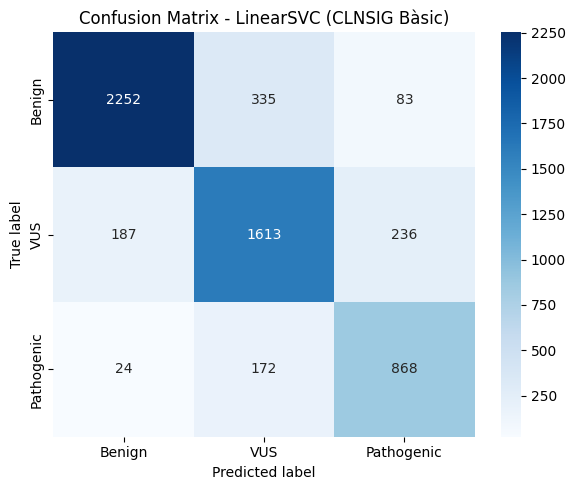

In [9]:
# Model base
svc_basic = LinearSVC(random_state=42, max_iter=2000)

# Pipeline preprocessament + model
pipeline_svc_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", svc_basic)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_svc_basic = GridSearchCV(
    pipeline_svc_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_svc_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_svc_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_svc_basic.best_score_:.4f}")

best_svc_basic = grid_svc_basic.best_estimator_
y_pred_svc_basic = best_svc_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_svc_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_svc_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_svc_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_svc_basic),
    "Confusion Matrix - LinearSVC (CLNSIG Bàsic)"
)

## Logistic Regression L1 (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.01, 'model__class_weight': 'balanced'}
Millor CV F1 macro:  0.7887

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.91      0.84      0.88      2670
         VUS       0.72      0.86      0.78      2036
  Pathogenic       0.83      0.68      0.75      1064

    accuracy                           0.82      5770
   macro avg       0.82      0.80      0.80      5770
weighted avg       0.83      0.82      0.82      5770


Test F1 macro: 0.8043
Confusion matrix:
[[2251  369   50]
 [ 188 1754   94]
 [  25  312  727]]


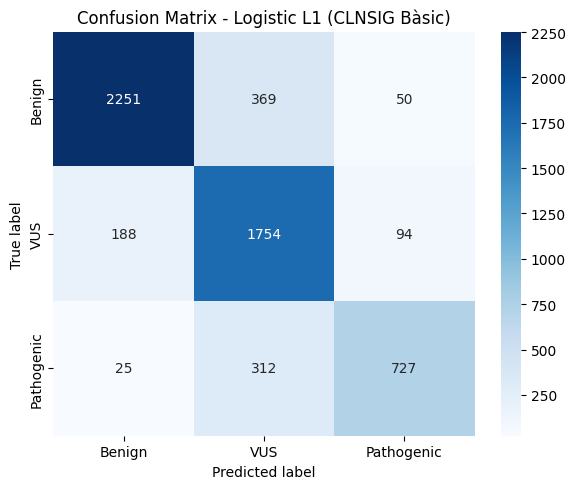

In [10]:

# Model base
lr_l1_basic = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_lr_l1_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", lr_l1_basic)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_lr_l1_basic = GridSearchCV(
    pipeline_lr_l1_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr_l1_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_lr_l1_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_lr_l1_basic.best_score_:.4f}")

best_lr_l1_basic = grid_lr_l1_basic.best_estimator_
y_pred_lr_l1_basic = best_lr_l1_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_lr_l1_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_lr_l1_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_lr_l1_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_lr_l1_basic),
    "Confusion Matrix - Logistic L1 (CLNSIG Bàsic)"
)

## Logistic Regression L2 (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.1, 'model__class_weight': None}
Millor CV F1 macro:  0.8156

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.93      0.83      0.88      2670
         VUS       0.72      0.90      0.80      2036
  Pathogenic       0.88      0.70      0.78      1064

    accuracy                           0.83      5770
   macro avg       0.85      0.81      0.82      5770
weighted avg       0.85      0.83      0.83      5770


Test F1 macro: 0.8205
Confusion matrix:
[[2227  398   45]
 [ 145 1837   54]
 [  20  303  741]]


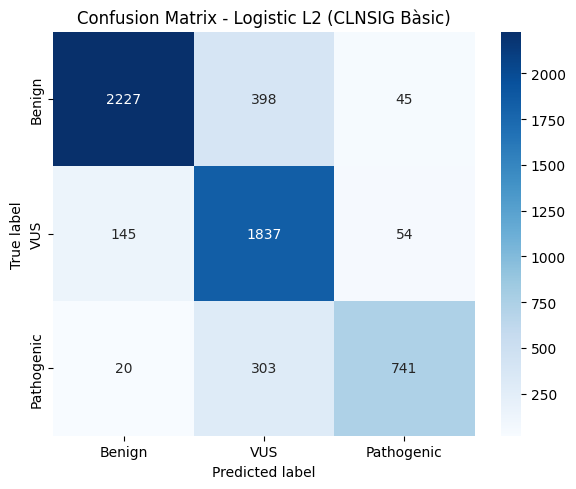

In [11]:

# Model base
lr_l2_basic = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# Pipeline preprocessament + model
pipeline_lr_l2_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", lr_l2_basic)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_lr_l2_basic = GridSearchCV(
    pipeline_lr_l2_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr_l2_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_lr_l2_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_lr_l2_basic.best_score_:.4f}")

best_lr_l2_basic = grid_lr_l2_basic.best_estimator_
y_pred_lr_l2_basic = best_lr_l2_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_lr_l2_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_lr_l2_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_lr_l2_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_lr_l2_basic),
    "Confusion Matrix - Logistic L2 (CLNSIG Bàsic)"
)

## Decision Tree (Bàsic)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Millors paràmetres: {'model__class_weight': None, 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 20}
Millor CV F1 macro:  0.8706

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.93      0.95      0.94      2670
         VUS       0.83      0.86      0.85      2036
  Pathogenic       0.88      0.78      0.83      1064

    accuracy                           0.88      5770
   macro avg       0.88      0.86      0.87      5770
weighted avg       0.88      0.88      0.88      5770


Test F1 macro: 0.8694
Confusion matrix:
[[2524  133   13]
 [ 183 1749  104]
 [  19  214  831]]


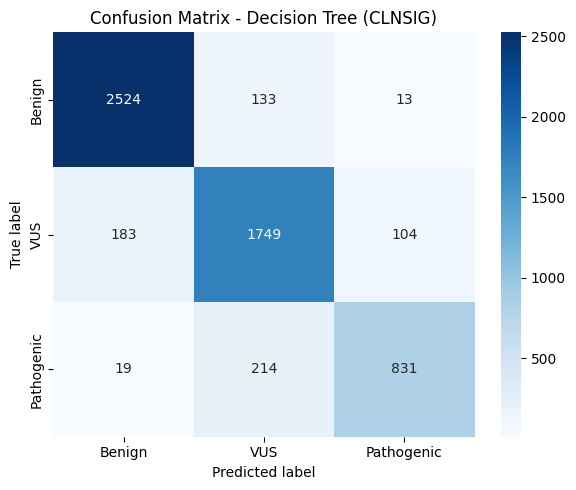

In [12]:

# Model base
dt = DecisionTreeClassifier(random_state=42)
 
# Pipeline preprocessament + model
pipeline_dt_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", dt)
])
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# Cerca d'hiperparàmetres
param_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}
 
grid_dt_basic = GridSearchCV(
    pipeline_dt_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)
 
grid_dt_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_dt_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_dt_basic.best_score_:.4f}")
 
best_dt_basic = grid_dt_basic.best_estimator_
y_pred_dt_basic = best_dt_basic.predict(X_test_basic)
 
print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_dt_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_dt_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_dt_basic)}")
 
plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_dt_basic),
    "Confusion Matrix - Decision Tree (CLNSIG)"
)

## Random Forest (Bàsic)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Millors paràmetres: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.3, 'model__max_depth': None, 'model__class_weight': None}
Millor CV F1 macro:  0.8837

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95      2670
         VUS       0.86      0.87      0.87      2036
  Pathogenic       0.88      0.80      0.84      1064

    accuracy                           0.90      5770
   macro avg       0.89      0.88      0.88      5770
weighted avg       0.90      0.90      0.90      5770


Test F1 macro: 0.8835
Confusion matrix:
[[2579   82    9]
 [ 167 1764  105]
 [  21  196  847]]


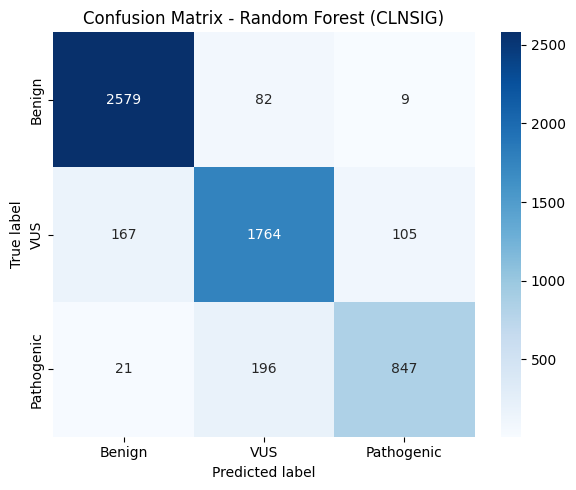

In [13]:
# Model base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Pipeline preprocessament + model
pipeline_rf_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_dist = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", 0.3],
    "model__class_weight":      [None, "balanced"]
}

random_search_rf_basic = RandomizedSearchCV(
    estimator=pipeline_rf_basic,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search_rf_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_rf_basic.best_params_}")
print(f"Millor CV F1 macro:  {random_search_rf_basic.best_score_:.4f}")

best_rf_basic = random_search_rf_basic.best_estimator_
y_pred_rf_basic = best_rf_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_rf_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_rf_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_rf_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_rf_basic),
    "Confusion Matrix - Random Forest (CLNSIG)"
)

## MLP (Bàsic)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Millors paràmetres: {'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (64,), 'model__alpha': 0.001}
Millor CV F1 macro:  0.7589

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.99      0.55      0.71      2670
         VUS       0.57      0.98      0.72      2036
  Pathogenic       0.94      0.69      0.80      1064

    accuracy                           0.73      5770
   macro avg       0.83      0.74      0.74      5770
weighted avg       0.83      0.73      0.73      5770


Test F1 macro: 0.7421
Confusion matrix:
[[1477 1180   13]
 [  11 1995   30]
 [   3  329  732]]


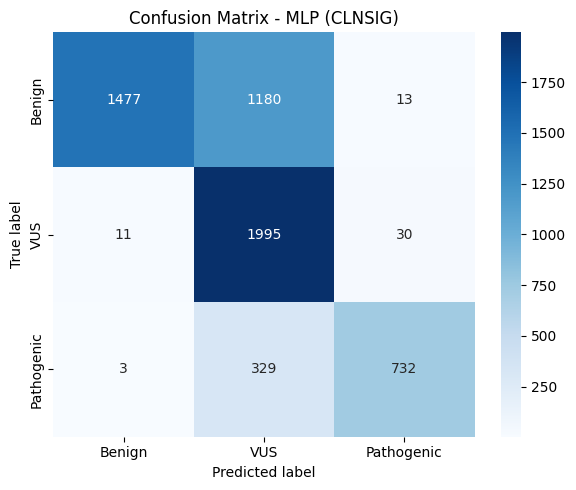

In [ ]:
# Es silencien tres tipus d'avisos que apareixen de manera recurrent durant l'entrenament i no indiquen errors
# A més de no ser errors, es generen en gran quantitat i, en quedar desats dins
# del fitxer .ipynb, n'augmenten molt la mida, per això se silencien.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Model base
mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    max_iter=500,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_mlp_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_dist = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha":              [1e-3, 5e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
}

random_search_mlp_basic = RandomizedSearchCV(
    estimator=pipeline_mlp_basic,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1,
    refit=True,
    error_score="raise"
)

random_search_mlp_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_mlp_basic.best_params_}")
print(f"Millor CV F1 macro:  {random_search_mlp_basic.best_score_:.4f}")

best_mlp_basic = random_search_mlp_basic.best_estimator_
y_pred_mlp_basic = best_mlp_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_mlp_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_mlp_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_mlp_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_mlp_basic),
    "Confusion Matrix - MLP (CLNSIG)"
)

## Comparació Models – Annotated vs Bàsic

In [15]:
import pickle
import os

# Carregar resultats anotats (validació creuada + test) per a cada model
pkl_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results_clnsig_annotated.pkl')
with open(pkl_path, 'rb') as f:
    _ann = pickle.load(f)

# Classe auxiliar per accedir als resultats anotats com a atributs
class _Score:
    def __init__(self, v): self.best_score_ = v

grid_dt             = _Score(_ann['dt_cv'])
random_search_rf    = _Score(_ann['rf_cv'])
random_search_mlp   = _Score(_ann['mlp_cv'])
grid_lr_l2          = _Score(_ann['l2_cv'])
grid_lr_l1          = _Score(_ann['l1_cv'])
grid_svc            = _Score(_ann['svc_cv'])
y_test              = _ann['y_test']
y_pred_dt           = _ann['y_pred_dt']
y_pred_rf           = _ann['y_pred_rf']
y_pred_mlp          = _ann['y_pred_mlp']
y_pred_lr_l2        = _ann['y_pred_lr_l2']
y_pred_lr_l1        = _ann['y_pred_lr_l1']
y_pred_svc          = _ann['y_pred_svc']
CLASS_NAMES         = _ann['CLASS_NAMES']

print('Resultats annotated carregats correctament')

Resultats annotated carregats correctament


## Comparació de Models

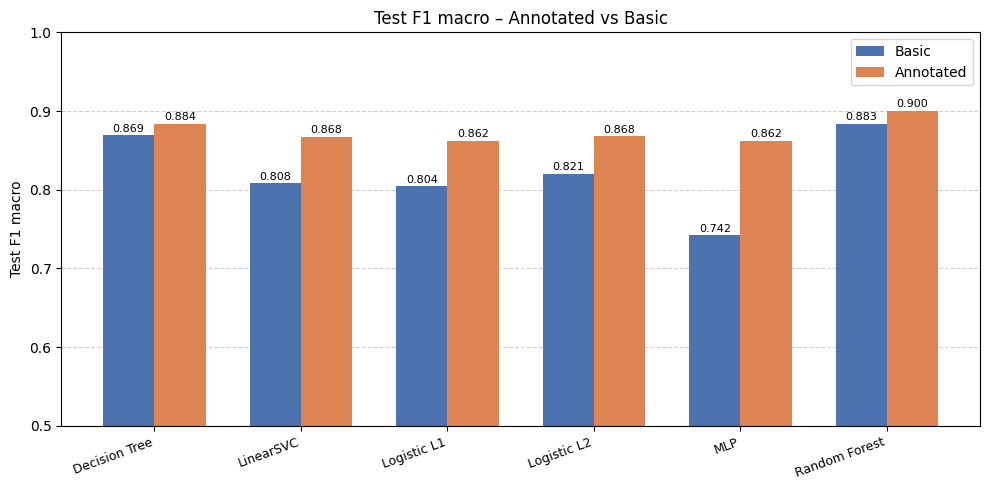

In [16]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = [
    ("Decision Tree", "Annotated", grid_dt.best_score_,                 y_test,       y_pred_dt),
    ("Random Forest", "Annotated", random_search_rf.best_score_,        y_test,       y_pred_rf),
    ("MLP",           "Annotated", random_search_mlp.best_score_,       y_test,       y_pred_mlp),
    ("Logistic L2",   "Annotated", grid_lr_l2.best_score_,              y_test,       y_pred_lr_l2),
    ("Logistic L1",   "Annotated", grid_lr_l1.best_score_,              y_test,       y_pred_lr_l1),
    ("LinearSVC",     "Annotated", grid_svc.best_score_,                y_test,       y_pred_svc),
    ("Decision Tree", "Basic",     grid_dt_basic.best_score_,           y_test_basic, y_pred_dt_basic),
    ("Random Forest", "Basic",     random_search_rf_basic.best_score_,  y_test_basic, y_pred_rf_basic),
    ("MLP",           "Basic",     random_search_mlp_basic.best_score_, y_test_basic, y_pred_mlp_basic),
    ("Logistic L2",   "Basic",     grid_lr_l2_basic.best_score_,        y_test_basic, y_pred_lr_l2_basic),
    ("Logistic L1",   "Basic",     grid_lr_l1_basic.best_score_,        y_test_basic, y_pred_lr_l1_basic),
    ("LinearSVC",     "Basic",     grid_svc_basic.best_score_,          y_test_basic, y_pred_svc_basic),
]

rows = []
for name, dataset, cv_f1, y_true, y_pred in models:
    rep = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    rows.append({
        "Model":         name,
        "Dataset":       dataset,
        "CV F1 macro":   round(cv_f1, 4),
        "Test F1 macro": round(rep["macro avg"]["f1-score"], 4),
        "Test Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "F1 Benign":     round(rep["Benign"]["f1-score"], 4),
        "F1 VUS":        round(rep["VUS"]["f1-score"], 4),
        "F1 Pathogenic": round(rep["Pathogenic"]["f1-score"], 4),
    })

df_results = pd.DataFrame(rows)

pivot = df_results.pivot(index="Model", columns="Dataset", values="Test F1 macro")

model_names = pivot.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, pivot["Basic"],     width, label="Basic",     color="#4C72B0")
ax.bar(x + width/2, pivot["Annotated"], width, label="Annotated", color="#DD8452")

for i, (b, a) in enumerate(zip(pivot["Basic"], pivot["Annotated"])):
    ax.text(i - width/2, b + 0.002, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, a + 0.002, f"{a:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0.50, 1.00)
ax.set_ylabel("Test F1 macro")
ax.set_title("Test F1 macro – Annotated vs Basic")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Interpretabilitat SHAP
Anàlisi d'interpretabilitat dels sis models entrenats mitjançant 
valors SHAP.

In [17]:
def normalize_sv_list(sv_raw):
    """Retorna llista de arrays 2D (n_samples, n_features) per classe."""
    if isinstance(sv_raw, list):
        return [np.array(sv, dtype=np.float64) for sv in sv_raw]
    sv_raw = np.array(sv_raw, dtype=np.float64)
    if sv_raw.ndim == 3:
        return [sv_raw[:, :, c] for c in range(sv_raw.shape[2])]
    return [sv_raw]


def plot_shap_multiclass(sv_list, feature_names, model_title,
                         class_names=CLASS_NAMES, top_k=15):
    clean = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

    global_abs = np.mean([np.abs(sv).mean(axis=0) for sv in sv_list], axis=0)
    global_df = pd.DataFrame({"feature": clean, "importance": global_abs})
    top_global = global_df.nlargest(top_k, "importance").sort_values("importance")

    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"], top_global["importance"], color="#4C72B0")
    plt.title(f"{model_title} – Importància global SHAP (Top {top_k})")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    top_features = top_global["feature"].tolist()
    fig, axes = plt.subplots(1, len(class_names),
                             figsize=(6 * len(class_names), 7), sharey=True)
    if len(class_names) == 1:
        axes = [axes]
    for i, (sv, cn) in enumerate(zip(sv_list, class_names)):
        mean_signed = sv.mean(axis=0)
        sdf = pd.DataFrame({"feature": clean, "shap": mean_signed})
        sdf = (sdf[sdf["feature"].isin(top_features)]
               .drop_duplicates("feature")
               .set_index("feature")
               .reindex(top_features)
               .sort_values("shap"))
        colors = ["#C44E52" if x < 0 else "#4C72B0" for x in sdf["shap"]]
        axes[i].barh(sdf.index, sdf["shap"], color=colors)
        axes[i].axvline(0, color="black", linewidth=1)
        axes[i].set_title(f"Classe: {cn}")
        axes[i].set_xlabel("Mean SHAP value")
    fig.suptitle(f"{model_title} – SHAP signat per classe", fontsize=13)
    plt.tight_layout()
    plt.show()


def get_normalized_shap_multiclass(sv_list, feature_names):
    global_abs = np.mean([np.abs(sv).mean(axis=0) for sv in sv_list], axis=0)
    total = global_abs.sum() or 1
    clean = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
    return pd.Series(global_abs / total, index=clean)


def plot_cross_model_shap(meta_df, model_cols, title_suffix):
    top15 = meta_df.sort_values("mean_rank").head(15)
    print(f"Top 15 features més consistents entre models ({title_suffix}):")
    display(top15[model_cols + ["mean_across_models", "mean_rank"]].round(4))

    plt.figure(figsize=(9, 8))
    sns.heatmap(top15[model_cols], annot=True, fmt=".3f",
                cmap="YlOrRd", linewidths=0.5)
    plt.title(f"Importància SHAP normalitzada – Top 15 ({title_suffix})")
    plt.tight_layout()
    plt.show()

    top15_r = meta_df.sort_values("mean_rank").head(15).copy()
    top15_r["feature"] = top15_r.index
    plt.figure(figsize=(10, 7))
    plt.barh(top15_r["feature"][::-1], top15_r["mean_rank"][::-1], color="#4C72B0")
    plt.title(f"Ranking mitjà entre models – {title_suffix}")
    plt.xlabel("Mean rank")
    plt.tight_layout()
    plt.show()


def shorten(name, n=35):
    name = name.replace("num__", "").replace("cat__", "")
    return name[:n] + "..." if len(name) > n else name


### Models lineals

Càlcul dels valors SHAP per als tres models lineals mitjançant 
`LinearExplainer`. Aquesta implementació és exacta i computacionalment 
molt eficient, ja que aprofita els coeficients apresos del model.

Classes: 3, forma: (5770, 758)


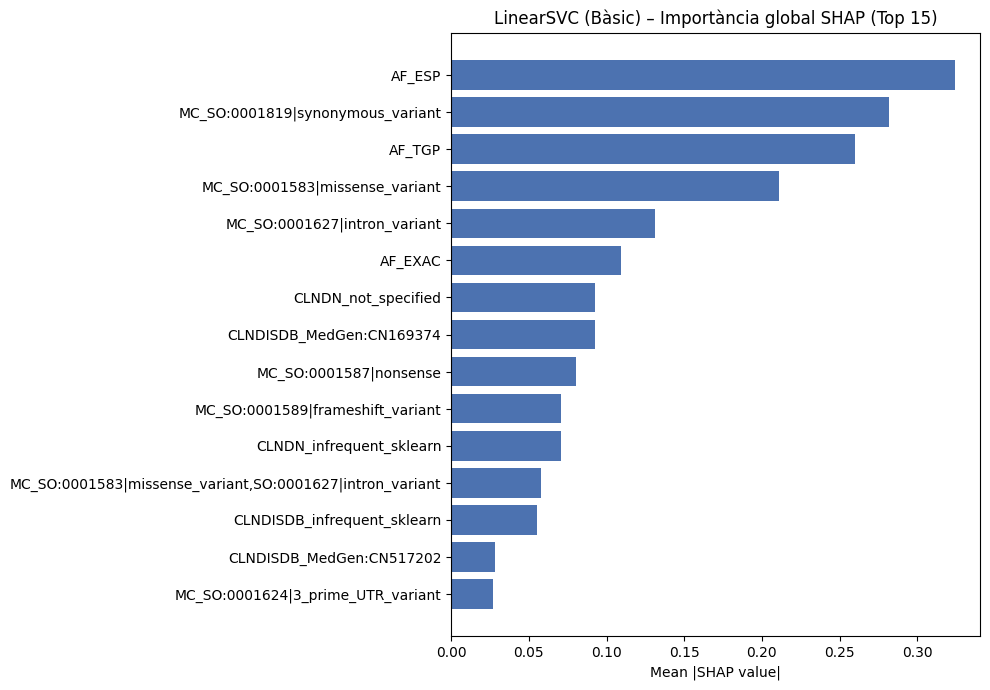

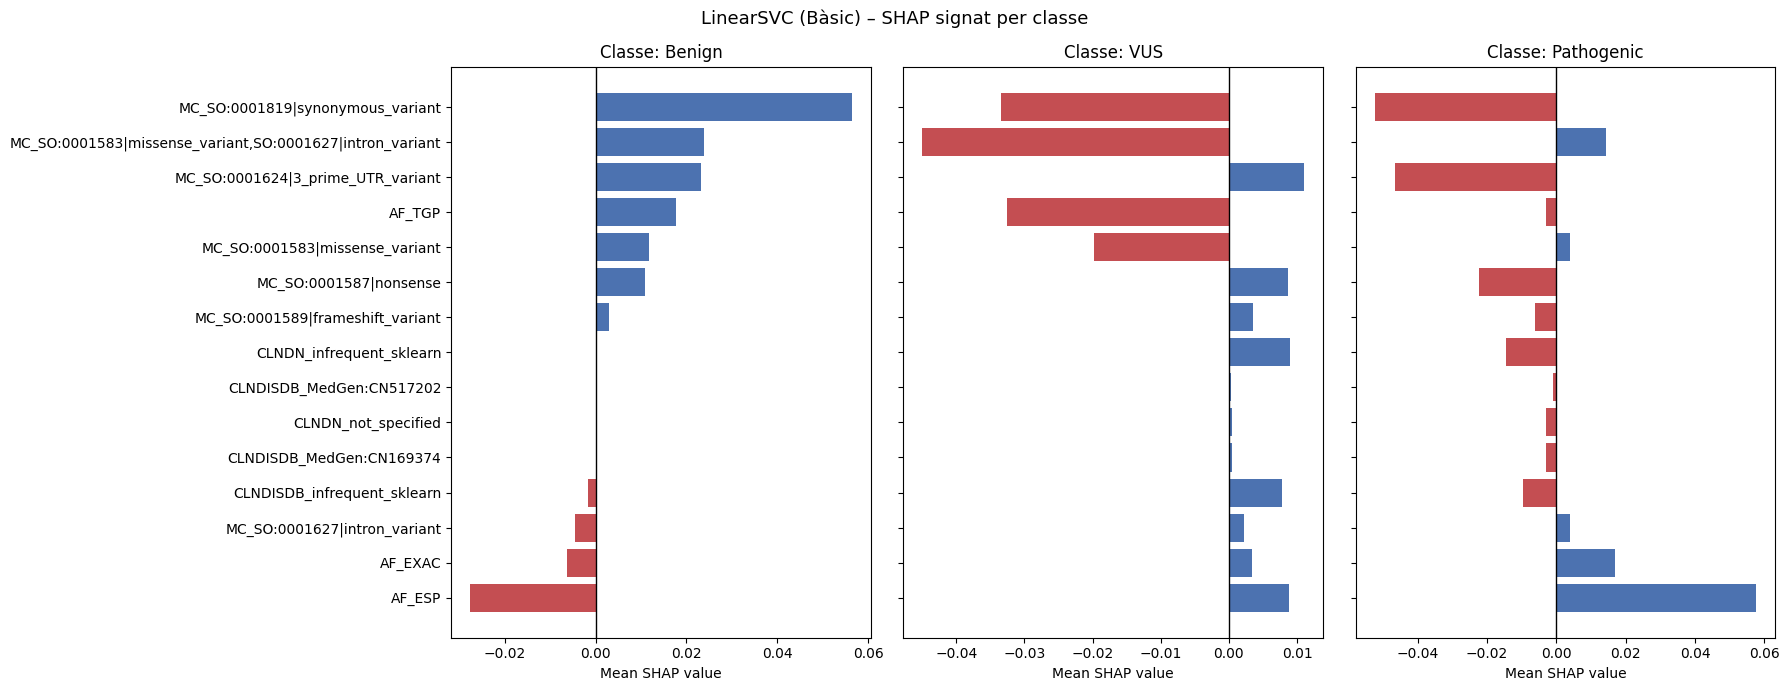

In [18]:
# Interpretabilitat SHAP per al millor LinearSVC (Bàsic)
X_test_tr_svc_b = best_svc_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_svc_b):
    X_test_tr_svc_b = X_test_tr_svc_b.toarray().astype(np.float64)
else:
    X_test_tr_svc_b = np.array(X_test_tr_svc_b, dtype=np.float64)

# Obtenir noms de les features després del preprocessament
feature_names_svc_b = best_svc_basic.named_steps["preprocess"].get_feature_names_out()
explainer_svc_b = shap.LinearExplainer(best_svc_basic.named_steps["model"], X_test_tr_svc_b)
shap_values_svc_b_raw = explainer_svc_b.shap_values(X_test_tr_svc_b)
sv_list_svc_b = normalize_sv_list(shap_values_svc_b_raw)

print(f"Classes: {len(sv_list_svc_b)}, forma: {sv_list_svc_b[0].shape}")
plot_shap_multiclass(sv_list_svc_b, feature_names_svc_b, "LinearSVC (Bàsic)")

Classes: 3, forma: (5770, 758)


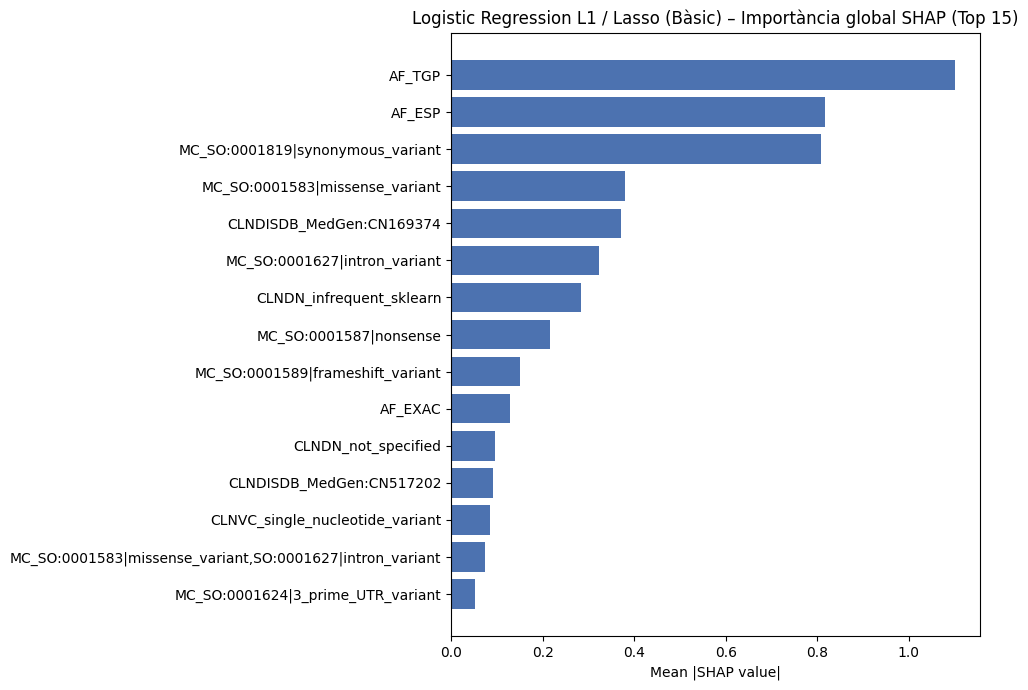

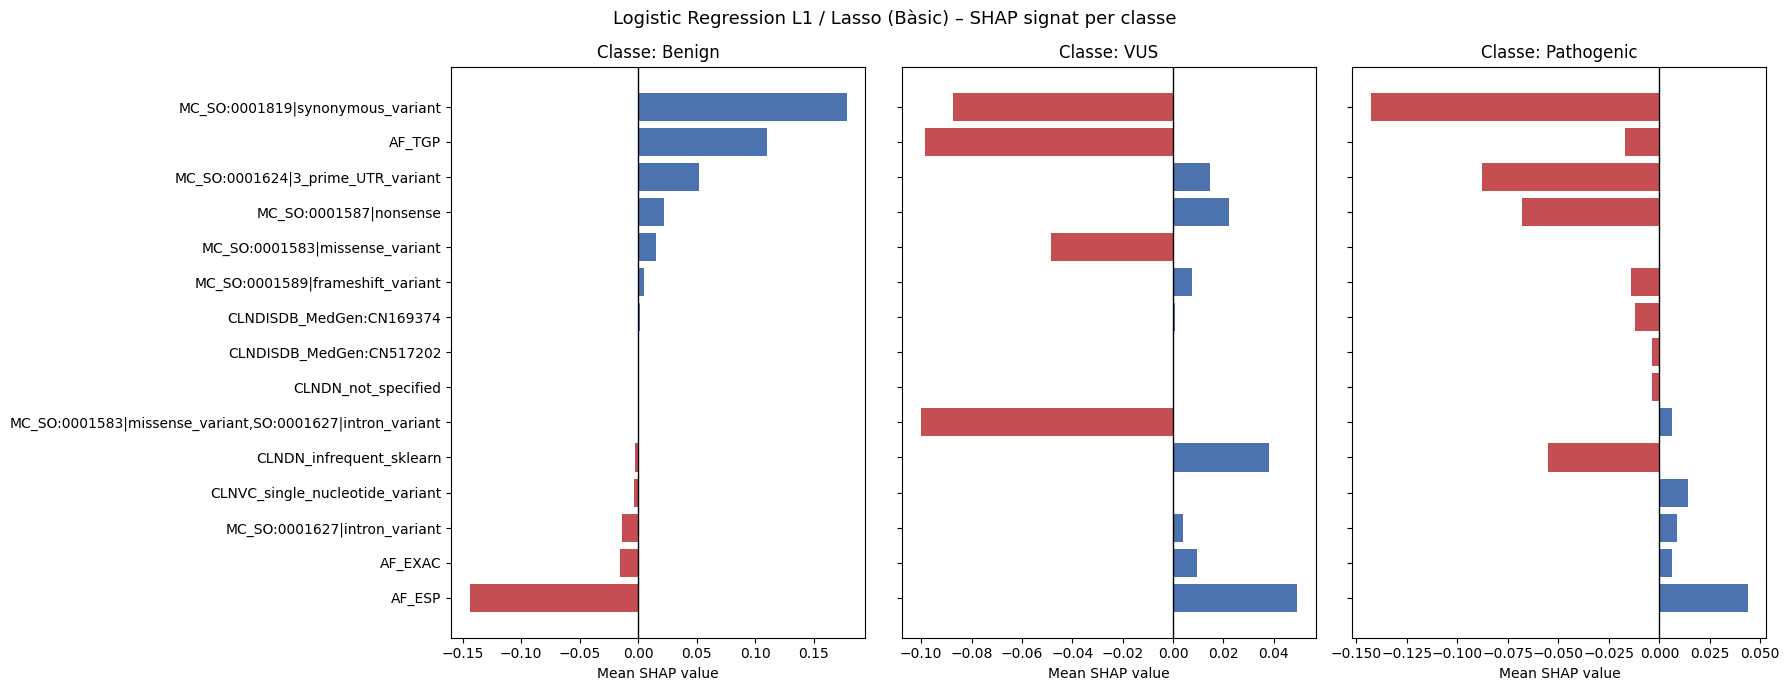

In [19]:
# Interpretabilitat SHAP per al millor Logistic Regression L1 (Bàsic)
X_test_tr_lr_l1_b = best_lr_l1_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_lr_l1_b):
    X_test_tr_lr_l1_b = X_test_tr_lr_l1_b.toarray().astype(np.float64)
else:
    X_test_tr_lr_l1_b = np.array(X_test_tr_lr_l1_b, dtype=np.float64)

# Obtenir noms de les features després del preprocessament
feature_names_lr_l1_b = best_lr_l1_basic.named_steps["preprocess"].get_feature_names_out()
explainer_lr_l1_b = shap.LinearExplainer(best_lr_l1_basic.named_steps["model"], X_test_tr_lr_l1_b)
shap_values_lr_l1_b_raw = explainer_lr_l1_b.shap_values(X_test_tr_lr_l1_b)
sv_list_lr_l1_b = normalize_sv_list(shap_values_lr_l1_b_raw)

print(f"Classes: {len(sv_list_lr_l1_b)}, forma: {sv_list_lr_l1_b[0].shape}")
plot_shap_multiclass(sv_list_lr_l1_b, feature_names_lr_l1_b, "Logistic Regression L1 / Lasso (Bàsic)")

Classes: 3, forma: (5770, 758)


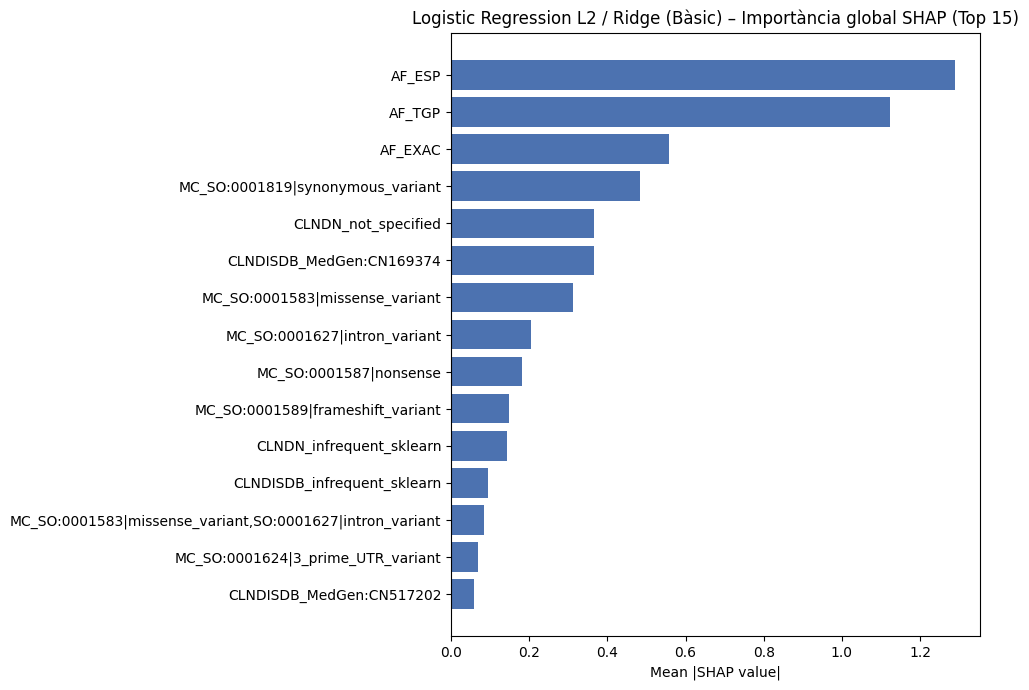

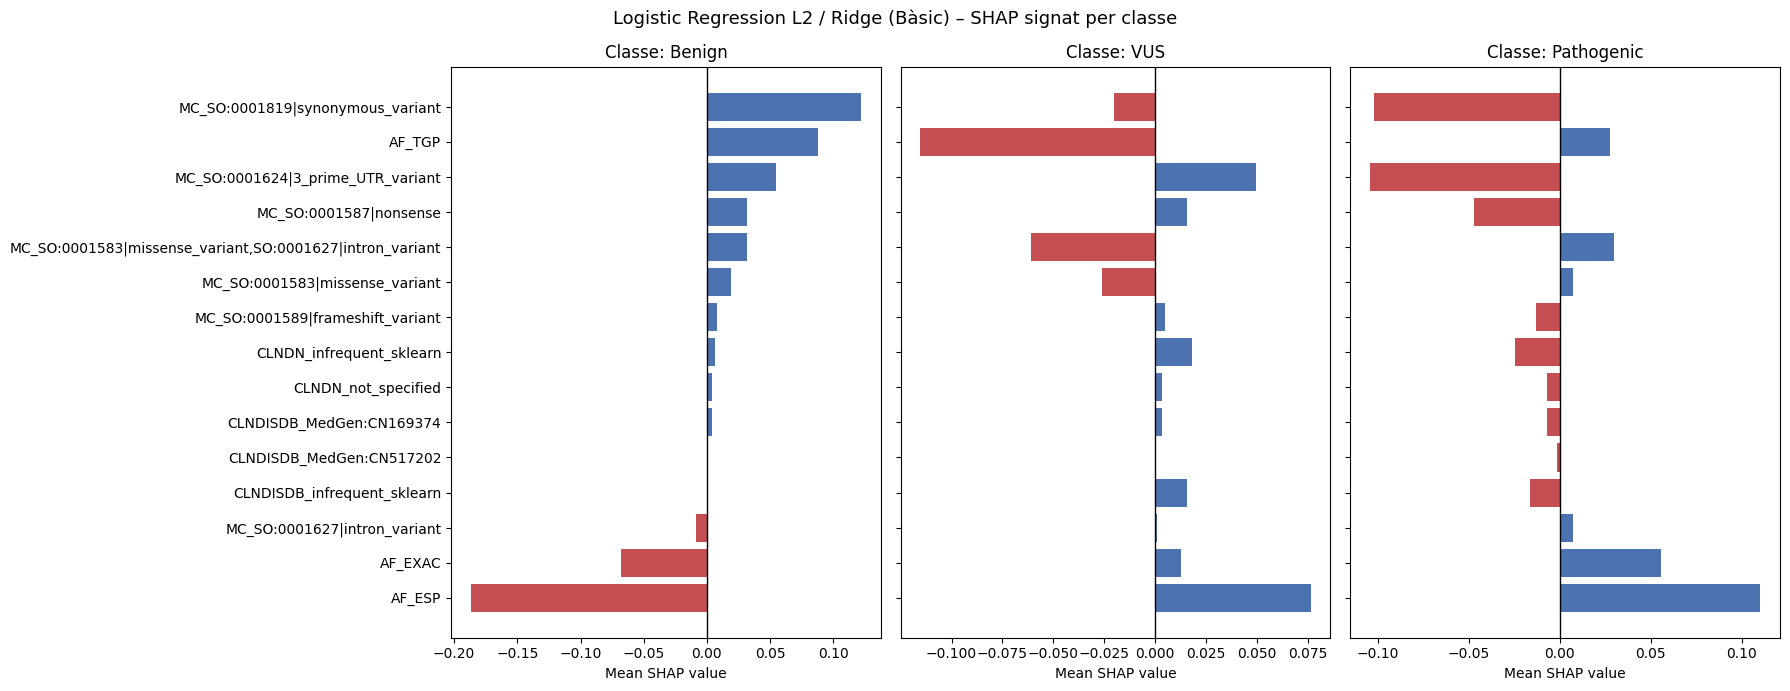

In [20]:
# Interpretabilitat SHAP per al millor Logistic Regression L2 (Bàsic)
X_test_tr_lr_l2_b = best_lr_l2_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_lr_l2_b):
    X_test_tr_lr_l2_b = X_test_tr_lr_l2_b.toarray().astype(np.float64)
else:
    X_test_tr_lr_l2_b = np.array(X_test_tr_lr_l2_b, dtype=np.float64)

# Obtenir noms de les features després del preprocessament
feature_names_lr_l2_b = best_lr_l2_basic.named_steps["preprocess"].get_feature_names_out()
explainer_lr_l2_b = shap.LinearExplainer(best_lr_l2_basic.named_steps["model"], X_test_tr_lr_l2_b)
shap_values_lr_l2_b_raw = explainer_lr_l2_b.shap_values(X_test_tr_lr_l2_b)
sv_list_lr_l2_b = normalize_sv_list(shap_values_lr_l2_b_raw)

print(f"Classes: {len(sv_list_lr_l2_b)}, forma: {sv_list_lr_l2_b[0].shape}")
plot_shap_multiclass(sv_list_lr_l2_b, feature_names_lr_l2_b, "Logistic Regression L2 / Ridge (Bàsic)")

### Decision Tree

Càlcul dels valors SHAP mitjançant `TreeExplainer`, que aprofita 
l'estructura de l'arbre per obtenir valors exactes de manera eficient.

Classes: 3, forma: (5770, 758)


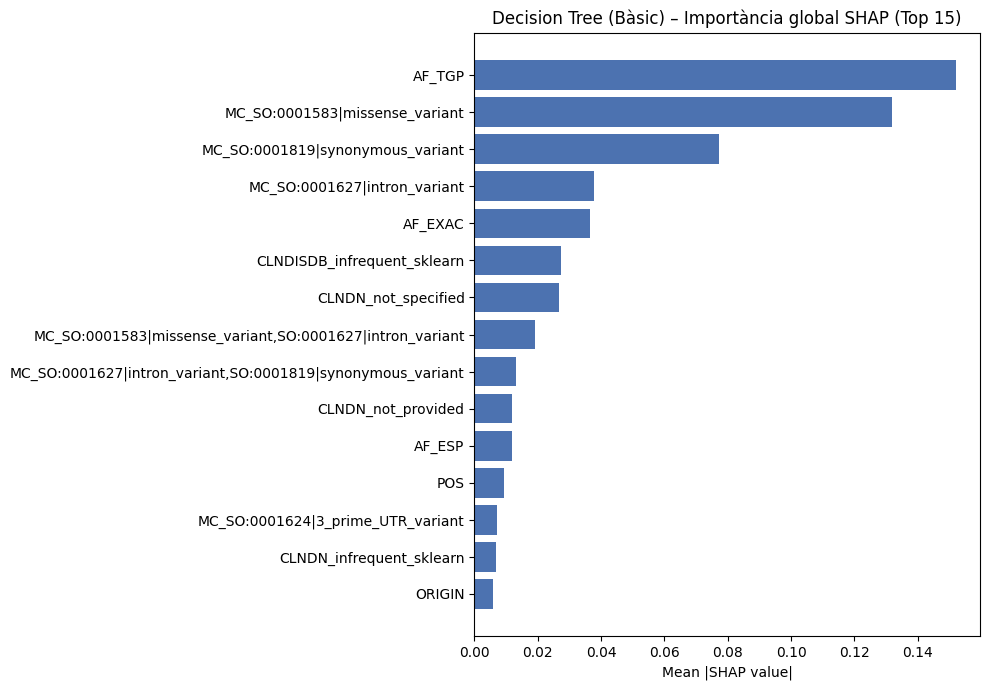

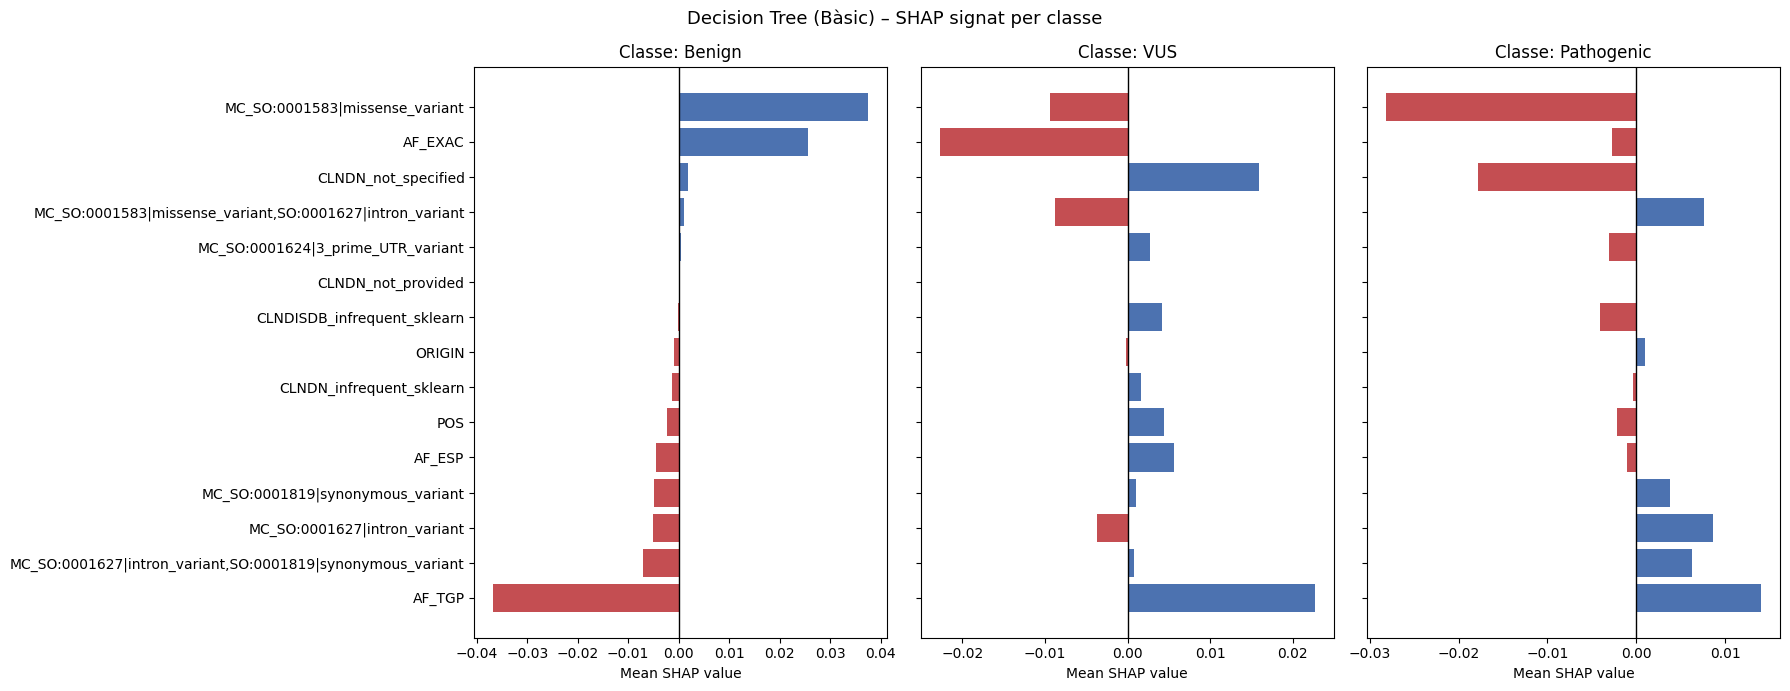

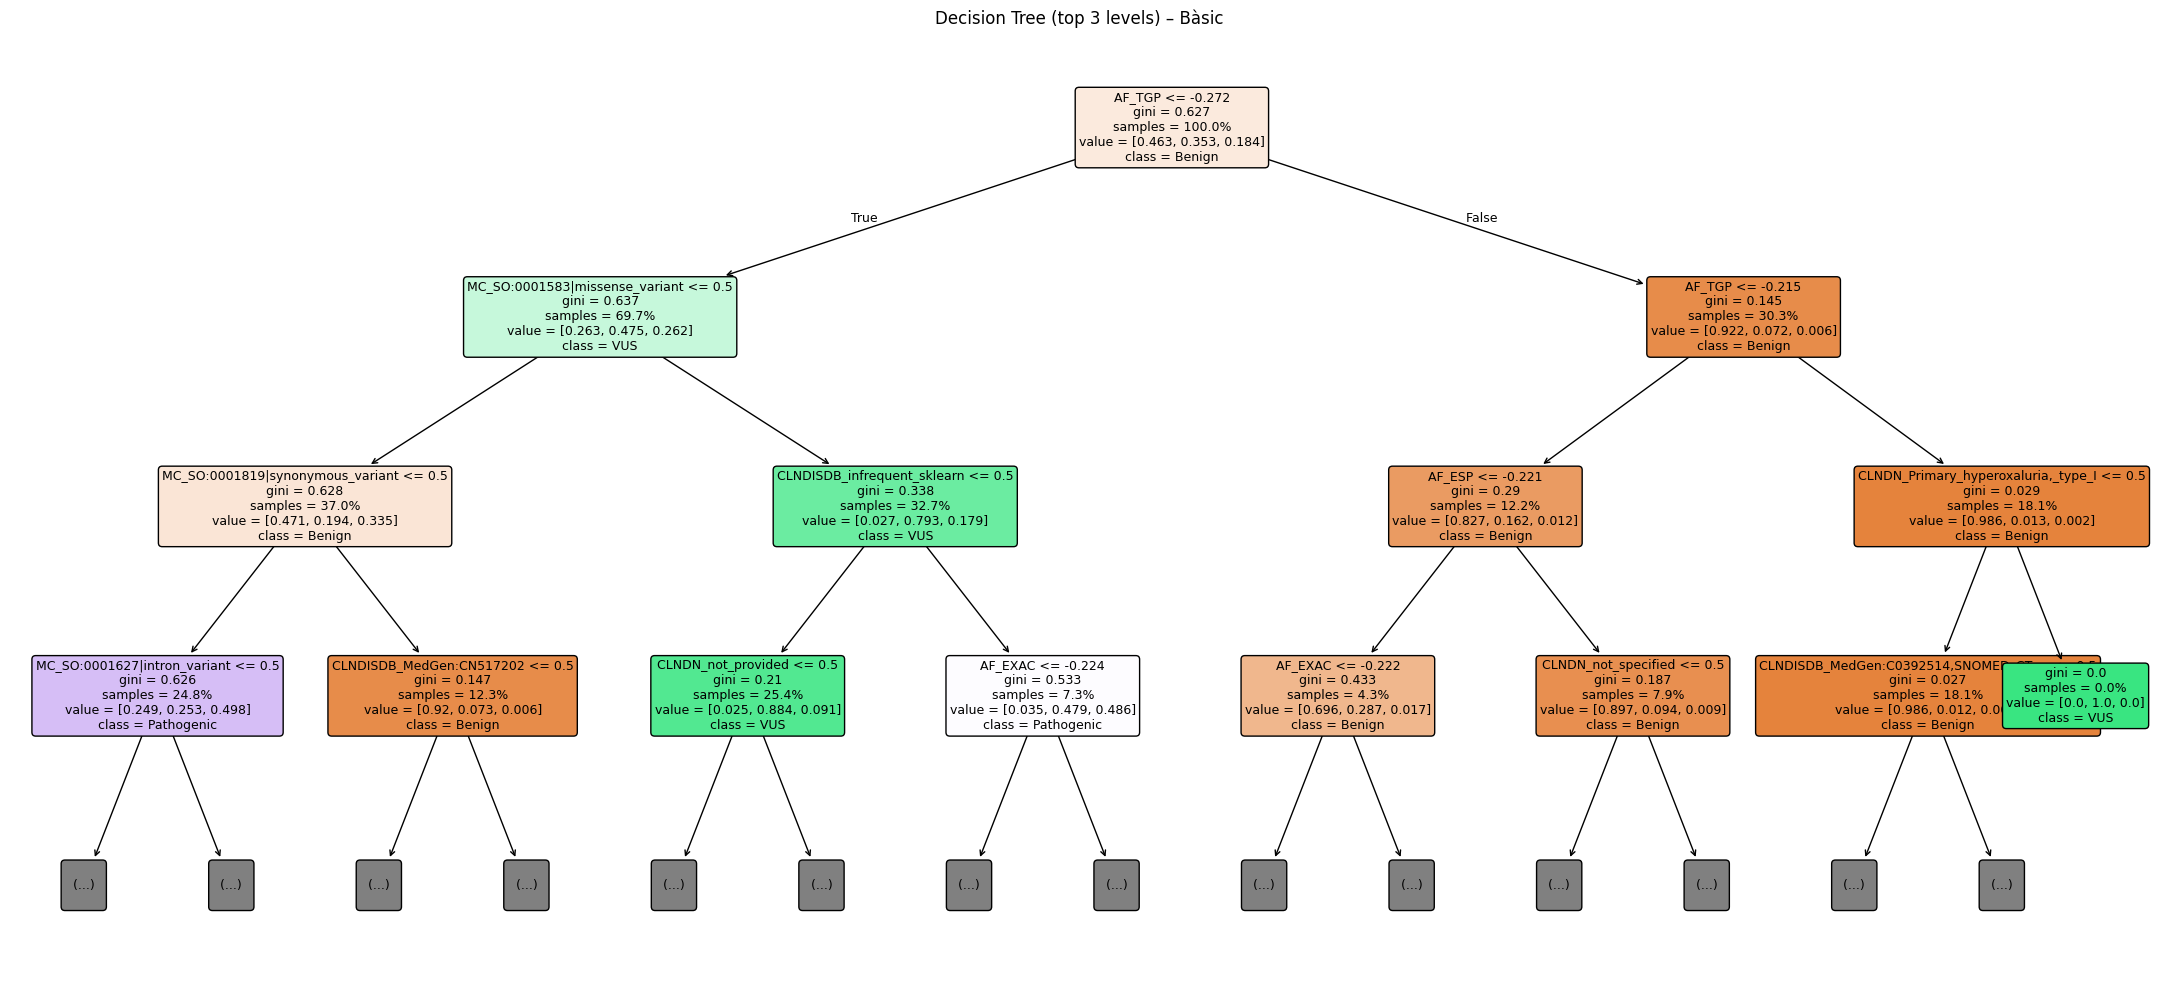

In [21]:
# SHAP per Decision Tree (Bàsic)
X_test_tr_dt_b = best_dt_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_dt_b):
    X_test_tr_dt_b = X_test_tr_dt_b.toarray().astype(np.float64)
else:
    X_test_tr_dt_b = np.array(X_test_tr_dt_b, dtype=np.float64)

# Obtenir noms de les features després del preprocessament
feature_names_dt_b = best_dt_basic.named_steps["preprocess"].get_feature_names_out()
explainer_dt_b = shap.TreeExplainer(best_dt_basic.named_steps["model"])
shap_values_dt_b_raw = explainer_dt_b.shap_values(X_test_tr_dt_b)
sv_list_dt_b = normalize_sv_list(shap_values_dt_b_raw)

print(f"Classes: {len(sv_list_dt_b)}, forma: {sv_list_dt_b[0].shape}")
plot_shap_multiclass(sv_list_dt_b, feature_names_dt_b, "Decision Tree (Bàsic)")

plt.figure(figsize=(22, 10))
plot_tree(
    best_dt_basic.named_steps["model"],
    feature_names=[shorten(f) for f in feature_names_dt_b],
    class_names=CLASS_NAMES,
    filled=True, rounded=True, max_depth=3,
    fontsize=9, impurity=True, proportion=True
)
plt.title("Decision Tree (top 3 levels) – Bàsic")
plt.tight_layout()
plt.show()

### Random Forest

Càlcul dels valors SHAP mitjançant `TreeExplainer` amb aproximació 
per conjunts d'arbres. S'utilitza `approximate=True` per reduir 
el cost computacional mantenint una estimació fiable.

Classes: 3, forma: (5770, 758)


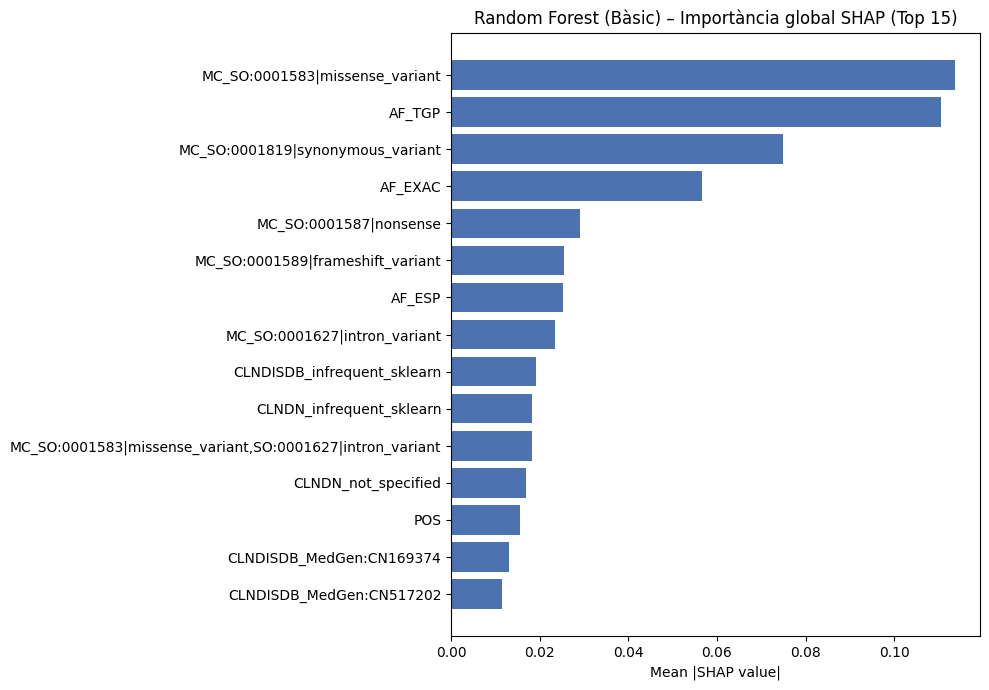

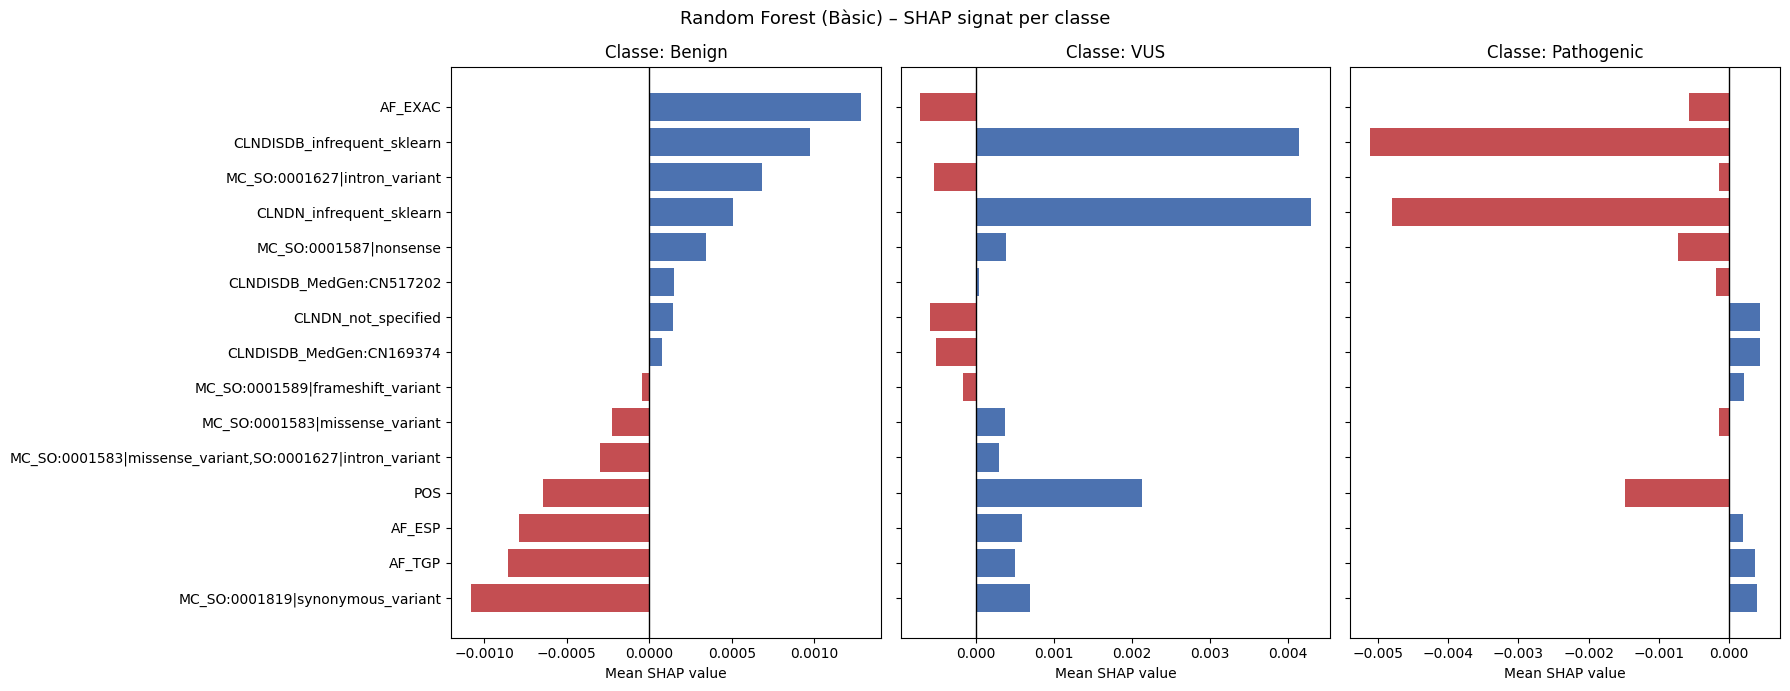

In [22]:
# SHAP per Random Forest (Bàsic)
X_test_tr_rf_b = best_rf_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_rf_b):
    X_test_tr_rf_b = X_test_tr_rf_b.toarray().astype(np.float64)
else:
    X_test_tr_rf_b = np.array(X_test_tr_rf_b, dtype=np.float64)

# Obtenir noms de les features després del preprocessament
feature_names_rf_b = best_rf_basic.named_steps["preprocess"].get_feature_names_out()
explainer_rf_b = shap.TreeExplainer(best_rf_basic.named_steps["model"])
shap_values_rf_b_raw = explainer_rf_b.shap_values(
    X_test_tr_rf_b, approximate=True, check_additivity=False
)
sv_list_rf_b = normalize_sv_list(shap_values_rf_b_raw)

print(f"Classes: {len(sv_list_rf_b)}, forma: {sv_list_rf_b[0].shape}")
plot_shap_multiclass(sv_list_rf_b, feature_names_rf_b, "Random Forest (Bàsic)")

### MLP

Càlcul dels valors SHAP mitjançant `KernelExplainer`, l'únic 
mètode aplicable a xarxes neuronals. 

X_test_tr_mlp_b shape: (5770, 758)


100%|██████████| 5770/5770 [01:23<00:00, 69.11it/s]


Classes: 3, forma: (5770, 758)


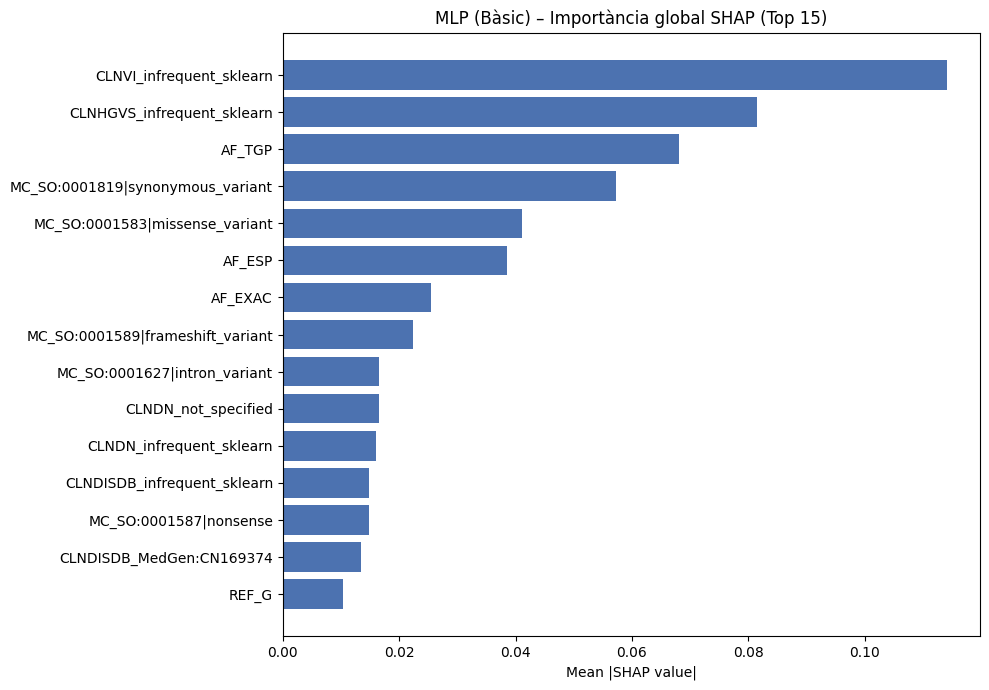

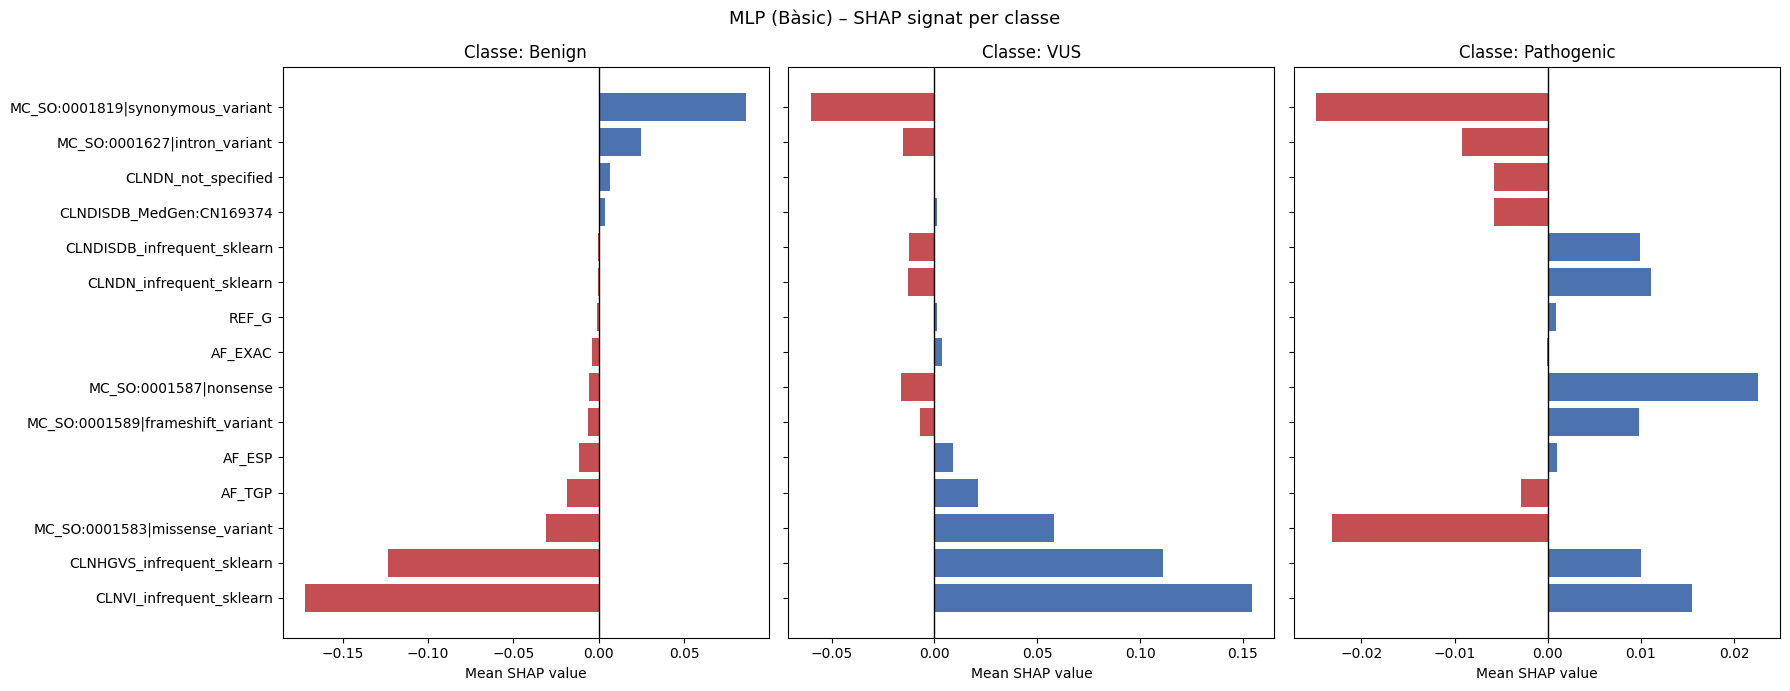

In [23]:
# S'han suprimit els warnings de tipus RuntimeWarning (overflow, divide by zero, etc.)
# ja que són habituals en Kernel SHAP degut a la resolució de sistemes lineals en espais
# d'alta dimensionalitat. Aquests warnings no afecten els resultats finals, però poden
# saturar la sortida i dificultar la interpretació dels resultats.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*matmul.*")
warnings.filterwarnings("ignore", message=".*overflow.*")
warnings.filterwarnings("ignore", message=".*divide by zero.*")

# SHAP per MLP (Bàsic) – utilitzem KernelExplainer per a models no lineals
X_test_tr_mlp_b = best_mlp_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_mlp_b):
    X_test_tr_mlp_b = X_test_tr_mlp_b.toarray().astype(np.float64)
else:
    X_test_tr_mlp_b = np.array(X_test_tr_mlp_b, dtype=np.float64)

X_train_tr_mlp_b = best_mlp_basic.named_steps["preprocess"].transform(X_train_val_basic)
if scipy.sparse.issparse(X_train_tr_mlp_b):
    X_train_tr_mlp_b = X_train_tr_mlp_b.toarray().astype(np.float64)
else:
    X_train_tr_mlp_b = np.array(X_train_tr_mlp_b, dtype=np.float64)

# Obtenir noms de les features després del preprocessament
feature_names_mlp_b = best_mlp_basic.named_steps["preprocess"].get_feature_names_out()
mlp_model_b = best_mlp_basic.named_steps["model"]

# Utilitzem k-means per resumir el conjunt de dades d'entrenament i accelerar el càlcul de SHAP
background_mlp_b = shap.kmeans(X_train_tr_mlp_b, 30)
print("X_test_tr_mlp_b shape:", X_test_tr_mlp_b.shape)

# Càlcul de SHAP values per al MLP (Bàsic) – pot trigar una mica
explainer_mlp_b = shap.KernelExplainer(mlp_model_b.predict_proba, background_mlp_b)
shap_values_mlp_b_raw = explainer_mlp_b.shap_values(X_test_tr_mlp_b, nsamples=100)
sv_list_mlp_b = normalize_sv_list(shap_values_mlp_b_raw)

print(f"Classes: {len(sv_list_mlp_b)}, forma: {sv_list_mlp_b[0].shape}")
plot_shap_multiclass(sv_list_mlp_b, feature_names_mlp_b, "MLP (Bàsic)")

## Comparació Interpretabilitat entre models

Top 15 features més consistents entre models (Bàsic):


,Decision Tree,Random Forest,MLP,Logistic L2,Logistic L1,Linear SVC,mean_across_models,mean_rank
AF_TGP,0.2429,0.1563,0.0978,0.1791,0.2099,0.1147,0.1668,2.0000
MC_SO:0001819|synonymous_variant,0.1234,0.1061,0.0821,0.0771,0.1542,0.1242,0.1112,3.1667
MC_SO:0001583|missense_variant,0.2109,0.1608,0.0591,0.0495,0.0726,0.0932,0.1077,3.8333
AF_ESP,0.0189,0.0358,0.0553,0.2054,0.1557,0.1430,0.1023,4.6667
AF_EXAC,0.0580,0.0800,0.0366,0.0888,0.0244,0.0483,0.0560,5.8333
MC_SO:0001627|intron_variant,0.0601,0.0330,0.0237,0.0323,0.0615,0.0578,0.0448,6.6667
CLNDN_not_specified,0.0429,0.0238,0.0237,0.0581,0.0185,0.0407,0.0346,8.6667
CLNDN_infrequent_sklearn,0.0107,0.0259,0.0230,0.0229,0.0541,0.0311,0.0280,10.6667
CLNDISDB_infrequent_sklearn,0.0435,0.0271,0.0213,0.0151,0.0068,0.0244,0.0230,11.6667
MC_SO:0001587|nonsense,0.0016,0.0412,0.0213,0.0288,0.0410,0.0353,0.0282,12.1667


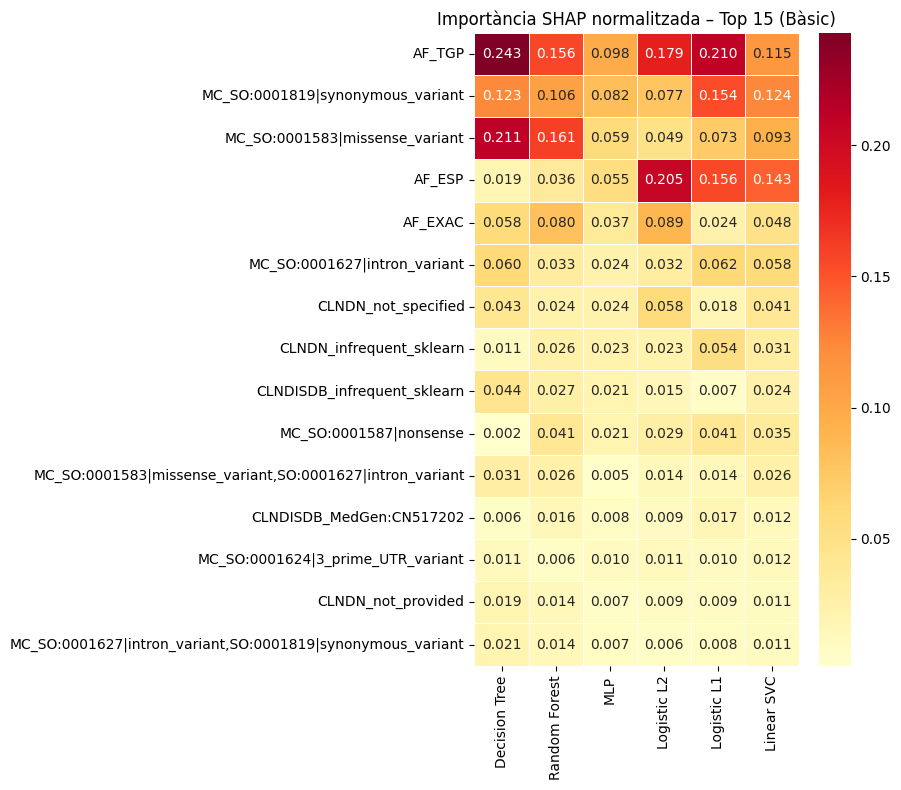

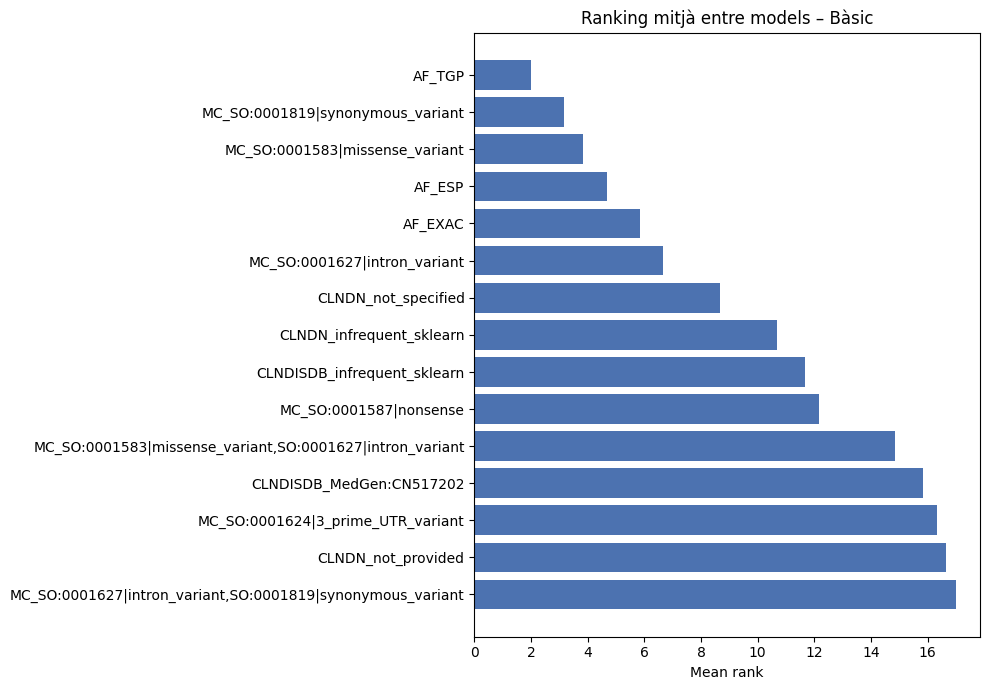

In [24]:
importance_dt_b    = get_normalized_shap_multiclass(sv_list_dt_b,    feature_names_dt_b)
importance_rf_b    = get_normalized_shap_multiclass(sv_list_rf_b,    feature_names_rf_b)
importance_mlp_b   = get_normalized_shap_multiclass(sv_list_mlp_b,   feature_names_mlp_b)
importance_lr_l2_b = get_normalized_shap_multiclass(sv_list_lr_l2_b, feature_names_lr_l2_b)
importance_lr_l1_b = get_normalized_shap_multiclass(sv_list_lr_l1_b, feature_names_lr_l1_b)
importance_svc_b   = get_normalized_shap_multiclass(sv_list_svc_b,   feature_names_svc_b)

meta_basic = pd.DataFrame({
    "Decision Tree": importance_dt_b,
    "Random Forest": importance_rf_b,
    "MLP":           importance_mlp_b,
    "Logistic L2":   importance_lr_l2_b,
    "Logistic L1":   importance_lr_l1_b,
    "Linear SVC":    importance_svc_b,
}).fillna(0)

model_cols_b = ["Decision Tree", "Random Forest", "MLP", "Logistic L2", "Logistic L1", "Linear SVC"]
meta_basic["mean_across_models"] = meta_basic[model_cols_b].mean(axis=1)
for col in model_cols_b:
    meta_basic[f"rank_{col}"] = meta_basic[col].rank(ascending=False).astype(int)
meta_basic["mean_rank"] = meta_basic[[f"rank_{col}" for col in model_cols_b]].mean(axis=1)

plot_cross_model_shap(meta_basic, model_cols_b, "Bàsic")